<a href="https://colab.research.google.com/github/421110016-a11y/metro-cdmx-dfs-bfs/blob/main/Metro_CDMX_DFS_BFS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Búsqueda de rutas en el Metro de la Ciudad de México

## Sistemas Inteligentes

### Objetivo

Modelar la red del Metro de la Ciudad de México mediante un grafo y utilizar
los algoritmos de búsqueda DFS (Depth-First Search) y BFS (Breadth-First Search)
para encontrar rutas entre diferentes estaciones.

Se utilizará un costo unitario:

Moverse de una estación a otra = 1.

### Rutas a analizar

1. Cuatro Caminos → Pantitlán
2. Politécnico → Tasqueña
3. Zapata → Oceanía

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

## 1. Librerías

Se utiliza NetworkX para representar y visualizar la red como un grafo.
Matplotlib se utiliza para generar las visualizaciones.

Los algoritmos DFS y BFS se implementan manualmente para estudiar
su funcionamiento y no dependen de las funciones de búsqueda de NetworkX.

## **Datos del metro**

Vamos a representar cada línea como una lista ordenada de estaciones.

In [10]:
linea_1 = [
    "Observatorio",
    "Tacubaya",
    "Juanacatlan",
    "Chapultepec",
    "Sevilla",
    "Insurgentes",
    "Cuauhtemoc",
    "Balderas",
    "Salto del Agua",
    "Isabel la Catolica",
    "Pino Suarez",
    "Merced",
    "Candelaria",
    "San Lazaro",
    "Moctezuma",
    "Balbuena",
    "Boulevard Puerto Aereo",
    "Gomez Farias",
    "Zaragoza",
    "Pantitlan"
]


linea_2 = [
    "Cuatro Caminos",
    "Panteones",
    "Tacuba",
    "Cuitlahuac",
    "Popotla",
    "Colegio Militar",
    "Normal",
    "San Cosme",
    "Revolucion",
    "Hidalgo",
    "Bellas Artes",
    "Allende",
    "Zocalo",
    "Pino Suarez",
    "San Antonio Abad",
    "Chabacano",
    "Viaducto",
    "Xola",
    "Villa de Cortes",
    "Nativitas",
    "Portales",
    "Ermita",
    "General Anaya",
    "Tasqueña"
]


linea_3 = [
    "Indios Verdes",
    "Deportivo 18 de Marzo",
    "Potrero",
    "La Raza",
    "Tlatelolco",
    "Guerrero",
    "Hidalgo",
    "Juarez",
    "Balderas",
    "Niños Heroes",
    "Hospital General",
    "Centro Medico",
    "Etiopia",
    "Eugenia",
    "Division del Norte",
    "Zapata",
    "Coyoacan",
    "Viveros",
    "Miguel Angel de Quevedo",
    "Copilco",
    "Universidad"
]


linea_4 = [
    "Martin Carrera",
    "Talisman",
    "Bondojito",
    "Consulado",
    "Canal del Norte",
    "Morelos",
    "Candelaria",
    "Fray Servando",
    "Jamaica",
    "Santa Anita"
]


linea_5 = [
    "Pantitlan",
    "Hangares",
    "Terminal Aerea",
    "Oceania",
    "Aragon",
    "Eduardo Molina",
    "Consulado",
    "Valle Gomez",
    "Misterios",
    "La Raza",
    "Autobuses del Norte",
    "Instituto del Petroleo",
    "Politecnico"
]


linea_6 = [
    "El Rosario",
    "Tezozomoc",
    "Azcapotzalco",
    "Ferreria",
    "Norte 45",
    "Vallejo",
    "Instituto del Petroleo",
    "Lindavista",
    "Deportivo 18 de Marzo",
    "La Villa-Basilica",
    "Martin Carrera"
]


linea_7 = [
    "El Rosario",
    "Aquiles Serdan",
    "Camarones",
    "Refineria",
    "Tacuba",
    "San Joaquin",
    "Polanco",
    "Auditorio",
    "Constituyentes",
    "Tacubaya",
    "San Pedro de los Pinos",
    "San Antonio",
    "Mixcoac",
    "Barranca del Muerto"
]


linea_8 = [
    "Garibaldi",
    "Bellas Artes",
    "San Juan de Letran",
    "Salto del Agua",
    "Doctores",
    "Obrera",
    "Chabacano",
    "La Viga",
    "Santa Anita",
    "Coyuya",
    "Iztacalco",
    "Apatlaco",
    "Aculco",
    "Escuadron 201",
    "Atlalilco",
    "Iztapalapa",
    "Cerro de la Estrella",
    "UAM-I",
    "Constitucion de 1917"
]


linea_9 = [
    "Tacubaya",
    "Patriotismo",
    "Chilpancingo",
    "Centro Medico",
    "Lazaro Cardenas",
    "Chabacano",
    "Jamaica",
    "Mixiuhca",
    "Velodromo",
    "Ciudad Deportiva",
    "Puebla",
    "Pantitlan"
]


linea_A = [
    "Pantitlan",
    "Agricola Oriental",
    "Canal de San Juan",
    "Tepalcates",
    "Guelatao",
    "Peñon Viejo",
    "Acatitla",
    "Santa Marta",
    "Los Reyes",
    "La Paz"
]


linea_B = [
    "Buenavista",
    "Guerrero",
    "Garibaldi",
    "Lagunilla",
    "Tepito",
    "Morelos",
    "San Lazaro",
    "Ricardo Flores Magon",
    "Romero Rubio",
    "Oceania",
    "Deportivo Oceania",
    "Bosque de Aragon",
    "Villa de Aragon",
    "Nezahualcoyotl",
    "Impulsora",
    "Rio de los Remedios",
    "Muzquiz",
    "Ecatepec",
    "Olimpica",
    "Plaza Aragon",
    "Ciudad Azteca"
]


linea_12 = [
    "Mixcoac",
    "Insurgentes Sur",
    "Hospital 20 de Noviembre",
    "Zapata",
    "Parque de los Venados",
    "Eje Central",
    "Ermita",
    "Mexicaltzingo",
    "Atlalilco",
    "Culhuacan",
    "San Andres Tomatlan",
    "Lomas Estrella",
    "Calle 11",
    "Periferico Oriente",
    "Tezonco",
    "Olivos",
    "Nopalera",
    "Zapotitlan",
    "Tlaltenco",
    "Tlahuac"
]

## **Creamos grafo**

La red se representa mediante un grafo no dirigido.

Cada estación es un vértice y cada conexión entre estaciones consecutivas
es una arista.

Se asigna un costo unitario de 1 a cada movimiento.

In [11]:
G = nx.Graph()

In [12]:
def agregar_linea(grafo, estaciones, nombre_linea):

    for i in range(len(estaciones) - 1):

        origen = estaciones[i]
        destino = estaciones[i + 1]

        grafo.add_edge(
            origen,
            destino,
            weight=1,
            linea=nombre_linea
        )

## **Agregamos las 12 lineas**

In [13]:
agregar_linea(G, linea_1, "L1")
agregar_linea(G, linea_2, "L2")
agregar_linea(G, linea_3, "L3")
agregar_linea(G, linea_4, "L4")
agregar_linea(G, linea_5, "L5")
agregar_linea(G, linea_6, "L6")
agregar_linea(G, linea_7, "L7")
agregar_linea(G, linea_8, "L8")
agregar_linea(G, linea_9, "L9")
agregar_linea(G, linea_A, "LA")
agregar_linea(G, linea_B, "LB")
agregar_linea(G, linea_12, "L12")

## **verificar grafo**

In [14]:
print("Número de estaciones:", G.number_of_nodes())
print("Número de conexiones:", G.number_of_edges())

Número de estaciones: 163
Número de conexiones: 183


In [15]:
print("\nPrimeras estaciones:")
print(list(G.nodes())[:20])


Primeras estaciones:
['Observatorio', 'Tacubaya', 'Juanacatlan', 'Chapultepec', 'Sevilla', 'Insurgentes', 'Cuauhtemoc', 'Balderas', 'Salto del Agua', 'Isabel la Catolica', 'Pino Suarez', 'Merced', 'Candelaria', 'San Lazaro', 'Moctezuma', 'Balbuena', 'Boulevard Puerto Aereo', 'Gomez Farias', 'Zaragoza', 'Pantitlan']


## **Verificar las estaaciones del ejercicio**

In [16]:
estaciones_ejercicio = [
    "Cuatro Caminos",
    "Pantitlan",
    "Politecnico",
    "Tasqueña",
    "Zapata",
    "Oceania"
]

for estacion in estaciones_ejercicio:

    if estacion in G:
        print(estacion, "-> OK")
    else:
        print(estacion, "-> NO ENCONTRADA")

Cuatro Caminos -> OK
Pantitlan -> OK
Politecnico -> OK
Tasqueña -> OK
Zapata -> OK
Oceania -> OK


## **Clase node**

In [17]:
class Node:

    def __init__(
        self,
        state,
        parent=None,
        path_cost=0
    ):

        self.state = state
        self.parent = parent
        self.path_cost = path_cost


    def path(self):

        ruta = []
        nodo = self

        while nodo is not None:

            ruta.append(nodo.state)

            nodo = nodo.parent

        return ruta[::-1]

* state       → estación actual
* parent      → estación desde la que llegamos
* path_cost   → costo acumulado

## **Implementacion de DFS**

DFS explora un camino tan profundamente como sea posible antes de retroceder.

Para implementar DFS se utiliza una pila bajo el principio LIFO
(Last In, First Out).

DFS permite encontrar una ruta hacia el objetivo, pero no garantiza
una ruta con el menor número de movimientos.

In [18]:
def dfs(grafo, inicio, objetivo):

    nodo_inicial = Node(inicio)

    frontera = [nodo_inicial]

    visitados = set()

    nodos_explorados = 0


    while frontera:

        nodo = frontera.pop()

        if nodo.state in visitados:
            continue

        visitados.add(nodo.state)

        nodos_explorados += 1


        if nodo.state == objetivo:

            return {
                "ruta": nodo.path(),
                "costo": nodo.path_cost,
                "explorados": nodos_explorados
            }


        vecinos = list(grafo.neighbors(nodo.state))


        for vecino in vecinos:

            if vecino not in visitados:

                hijo = Node(
                    state=vecino,
                    parent=nodo,
                    path_cost=nodo.path_cost + 1
                )

                frontera.append(hijo)


    return None

## **Implementacion de BFS**

BFS explora primero los nodos que se encuentran a menor profundidad.

Utiliza una cola bajo el principio FIFO (First In, First Out).

Debido a que cada movimiento del Metro tiene costo 1, BFS permite encontrar
una ruta con el menor número de movimientos entre el origen y el destino.

In [20]:
def bfs(grafo, inicio, objetivo):

    nodo_inicial = Node(inicio)

    frontera = deque([nodo_inicial])

    visitados = {inicio}

    nodos_explorados = 0


    while frontera:

        nodo = frontera.popleft()

        nodos_explorados += 1


        if nodo.state == objetivo:

            return {
                "ruta": nodo.path(),
                "costo": nodo.path_cost,
                "explorados": nodos_explorados
            }


        for vecino in grafo.neighbors(nodo.state):

            if vecino not in visitados:

                visitados.add(vecino)

                hijo = Node(
                    state=vecino,
                    parent=nodo,
                    path_cost=nodo.path_cost + 1
                )

                frontera.append(hijo)


    return None

## **RESULTADOS**

In [21]:
def mostrar_resultado(nombre, resultado):

    print("=" * 60)
    print(nombre)
    print("=" * 60)

    print("Ruta:")

    print(" -> ".join(resultado["ruta"]))

    print()
    print("Número de movimientos:", resultado["costo"])
    print("Nodos explorados:", resultado["explorados"])

## **RUTA 1**
Cuatro caminos --> Pantitlan

In [22]:
inicio = "Cuatro Caminos"
destino = "Pantitlan"

resultado_dfs_1 = dfs(G, inicio, destino)

resultado_bfs_1 = bfs(G, inicio, destino)

In [23]:
mostrar_resultado(
    "DFS: Cuatro Caminos -> Pantitlan",
    resultado_dfs_1
)

mostrar_resultado(
    "BFS: Cuatro Caminos -> Pantitlan",
    resultado_bfs_1
)

DFS: Cuatro Caminos -> Pantitlan
Ruta:
Cuatro Caminos -> Panteones -> Tacuba -> San Joaquin -> Polanco -> Auditorio -> Constituyentes -> Tacubaya -> Patriotismo -> Chilpancingo -> Centro Medico -> Lazaro Cardenas -> Chabacano -> Jamaica -> Mixiuhca -> Velodromo -> Ciudad Deportiva -> Puebla -> Pantitlan

Número de movimientos: 18
Nodos explorados: 19
BFS: Cuatro Caminos -> Pantitlan
Ruta:
Cuatro Caminos -> Panteones -> Tacuba -> San Joaquin -> Polanco -> Auditorio -> Constituyentes -> Tacubaya -> Patriotismo -> Chilpancingo -> Centro Medico -> Lazaro Cardenas -> Chabacano -> Jamaica -> Mixiuhca -> Velodromo -> Ciudad Deportiva -> Puebla -> Pantitlan

Número de movimientos: 18
Nodos explorados: 123


## **Ruta 2**
Politecnico --> Tasqueña

In [24]:
inicio = "Politecnico"
destino = "Tasqueña"

resultado_dfs_2 = dfs(G, inicio, destino)

resultado_bfs_2 = bfs(G, inicio, destino)

In [25]:
mostrar_resultado(
    "DFS: Politecnico -> Tasqueña",
    resultado_dfs_2
)

mostrar_resultado(
    "BFS: Politecnico -> Tasqueña",
    resultado_bfs_2
)

DFS: Politecnico -> Tasqueña
Ruta:
Politecnico -> Instituto del Petroleo -> Lindavista -> Deportivo 18 de Marzo -> La Villa-Basilica -> Martin Carrera -> Talisman -> Bondojito -> Consulado -> Valle Gomez -> Misterios -> La Raza -> Tlatelolco -> Guerrero -> Garibaldi -> Lagunilla -> Tepito -> Morelos -> San Lazaro -> Ricardo Flores Magon -> Romero Rubio -> Oceania -> Terminal Aerea -> Hangares -> Pantitlan -> Puebla -> Ciudad Deportiva -> Velodromo -> Mixiuhca -> Jamaica -> Chabacano -> Lazaro Cardenas -> Centro Medico -> Chilpancingo -> Patriotismo -> Tacubaya -> San Pedro de los Pinos -> San Antonio -> Mixcoac -> Insurgentes Sur -> Hospital 20 de Noviembre -> Zapata -> Parque de los Venados -> Eje Central -> Ermita -> General Anaya -> Tasqueña

Número de movimientos: 46
Nodos explorados: 94
BFS: Politecnico -> Tasqueña
Ruta:
Politecnico -> Instituto del Petroleo -> Autobuses del Norte -> La Raza -> Tlatelolco -> Guerrero -> Hidalgo -> Bellas Artes -> Allende -> Zocalo -> Pino Suarez -

## **RUTA 3**
ZAPATA--> OCENIA

In [26]:
inicio = "Zapata"
destino = "Oceania"

resultado_dfs_3 = dfs(G, inicio, destino)

resultado_bfs_3 = bfs(G, inicio, destino)

In [27]:
mostrar_resultado(
    "DFS: Zapata -> Oceania",
    resultado_dfs_3
)

mostrar_resultado(
    "BFS: Zapata -> Oceania",
    resultado_bfs_3
)

DFS: Zapata -> Oceania
Ruta:
Zapata -> Parque de los Venados -> Eje Central -> Ermita -> Mexicaltzingo -> Atlalilco -> Escuadron 201 -> Aculco -> Apatlaco -> Iztacalco -> Coyuya -> Santa Anita -> La Viga -> Chabacano -> Jamaica -> Mixiuhca -> Velodromo -> Ciudad Deportiva -> Puebla -> Pantitlan -> Hangares -> Terminal Aerea -> Oceania

Número de movimientos: 22
Nodos explorados: 47
BFS: Zapata -> Oceania
Ruta:
Zapata -> Division del Norte -> Eugenia -> Etiopia -> Centro Medico -> Lazaro Cardenas -> Chabacano -> Jamaica -> Fray Servando -> Candelaria -> San Lazaro -> Ricardo Flores Magon -> Romero Rubio -> Oceania

Número de movimientos: 13
Nodos explorados: 113


## **Comparación automática**

Podemos hacer que el proyecto genere una tabla final:

In [28]:
import pandas as pd

resultados = [
    {
        "Ruta": "Cuatro Caminos - Pantitlan",
        "Algoritmo": "DFS",
        "Movimientos": resultado_dfs_1["costo"],
        "Nodos explorados": resultado_dfs_1["explorados"]
    },
    {
        "Ruta": "Cuatro Caminos - Pantitlan",
        "Algoritmo": "BFS",
        "Movimientos": resultado_bfs_1["costo"],
        "Nodos explorados": resultado_bfs_1["explorados"]
    },

    {
        "Ruta": "Politecnico - Tasqueña",
        "Algoritmo": "DFS",
        "Movimientos": resultado_dfs_2["costo"],
        "Nodos explorados": resultado_dfs_2["explorados"]
    },
    {
        "Ruta": "Politecnico - Tasqueña",
        "Algoritmo": "BFS",
        "Movimientos": resultado_bfs_2["costo"],
        "Nodos explorados": resultado_bfs_2["explorados"]
    },

    {
        "Ruta": "Zapata - Oceania",
        "Algoritmo": "DFS",
        "Movimientos": resultado_dfs_3["costo"],
        "Nodos explorados": resultado_dfs_3["explorados"]
    },
    {
        "Ruta": "Zapata - Oceania",
        "Algoritmo": "BFS",
        "Movimientos": resultado_bfs_3["costo"],
        "Nodos explorados": resultado_bfs_3["explorados"]
    }
]

df_resultados = pd.DataFrame(resultados)

df_resultados

,Ruta,Algoritmo,Movimientos,Nodos explorados
0,Cuatro Caminos - Pantitlan,DFS,18,19
1,Cuatro Caminos - Pantitlan,BFS,18,123
2,Politecnico - Tasqueña,DFS,46,94
3,Politecnico - Tasqueña,BFS,20,146
4,Zapata - Oceania,DFS,22,47
5,Zapata - Oceania,BFS,13,113


## 5. Comparación de los algoritmos

Los algoritmos DFS y BFS utilizan estrategias diferentes para explorar el grafo.

DFS utiliza una pila y profundiza sobre una rama antes de explorar otras
alternativas. Por esta razón puede encontrar una solución rápidamente en
algunos casos, pero no garantiza que la ruta encontrada tenga el menor
número de movimientos.

BFS utiliza una cola y explora el grafo por niveles. Debido a que en este
modelo todas las conexiones tienen costo unitario, la primera vez que BFS
alcanza el objetivo corresponde a una ruta con el menor número de aristas.

Las métricas utilizadas para comparar los algoritmos son:

- Ruta encontrada.
- Número de movimientos.
- Número de nodos explorados.

In [29]:
def visualizar_ruta(grafo, resultado, titulo):

    ruta = resultado["ruta"]

    aristas_ruta = list(zip(ruta, ruta[1:]))

    plt.figure(figsize=(20, 15))

    pos = nx.spring_layout(
        grafo,
        seed=42
    )

    nx.draw(
        grafo,
        pos,
        node_size=50,
        width=0.5,
        with_labels=False
    )

    nx.draw_networkx_nodes(
        grafo,
        pos,
        nodelist=ruta,
        node_size=200
    )

    nx.draw_networkx_edges(
        grafo,
        pos,
        edgelist=aristas_ruta,
        width=3
    )

    nx.draw_networkx_labels(
        grafo,
        pos,
        labels={n: n for n in ruta},
        font_size=7
    )

    plt.title(titulo)
    plt.show()

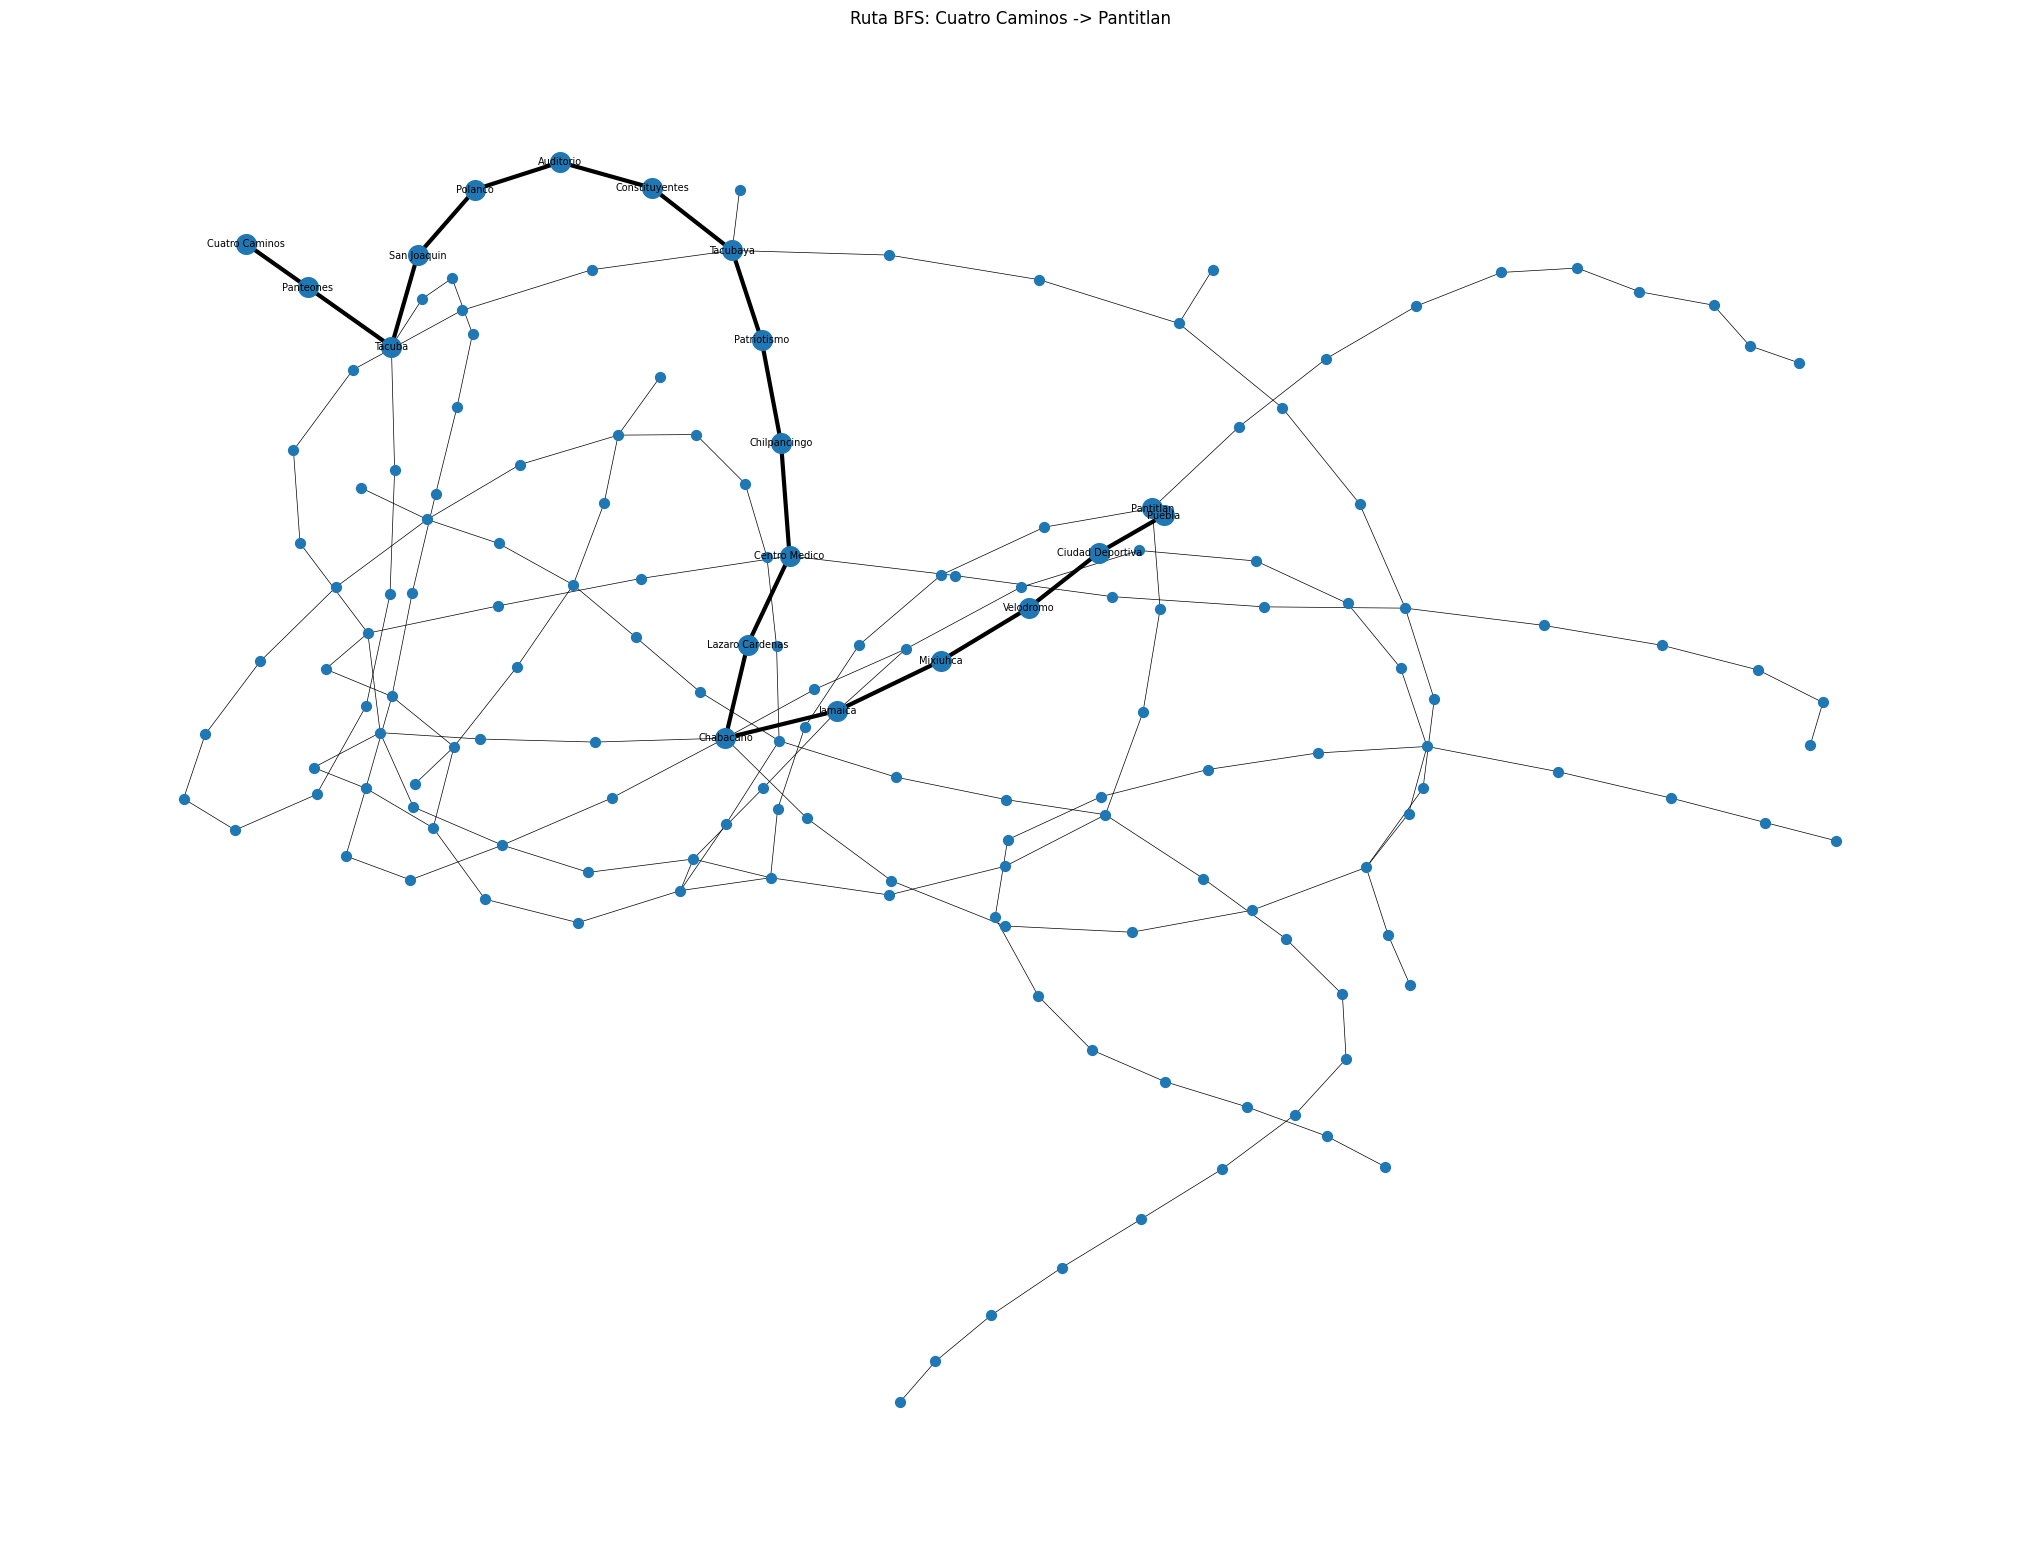

In [30]:
visualizar_ruta(
    G,
    resultado_bfs_1,
    "Ruta BFS: Cuatro Caminos -> Pantitlan"
)

# **Conclusiones**

En este proyecto se modeló la red del Metro de la Ciudad de México como
un grafo no dirigido, considerando cada estación como un nodo y cada
conexión entre estaciones consecutivas como una arista de costo unitario.

Posteriormente se implementaron desde cero los algoritmos DFS y BFS para
resolver tres problemas de búsqueda de rutas.

DFS realiza una exploración en profundidad utilizando una pila, mientras
que BFS realiza una exploración por niveles mediante una cola.

Al utilizar costos unitarios, BFS permite encontrar una ruta con el menor
número de movimientos entre dos estaciones.

El proyecto demuestra cómo los algoritmos clásicos de búsqueda utilizados
en Inteligencia Artificial pueden aplicarse a un problema real de movilidad
y transporte.

In [31]:
dfs(G, "Cuatro Caminos", "Pantitlan")
bfs(G, "Cuatro Caminos", "Pantitlan")

dfs(G, "Politecnico", "Tasqueña")
bfs(G, "Politecnico", "Tasqueña")

dfs(G, "Zapata", "Oceania")
bfs(G, "Zapata", "Oceania")

{'ruta': ['Zapata',
  'Division del Norte',
  'Eugenia',
  'Etiopia',
  'Centro Medico',
  'Lazaro Cardenas',
  'Chabacano',
  'Jamaica',
  'Fray Servando',
  'Candelaria',
  'San Lazaro',
  'Ricardo Flores Magon',
  'Romero Rubio',
  'Oceania'],
 'costo': 13,
 'explorados': 113}

In [32]:
# Ruta 1: Cuatro Caminos -> Pantitlan
dfs_1 = dfs(G, "Cuatro Caminos", "Pantitlan")
bfs_1 = bfs(G, "Cuatro Caminos", "Pantitlan")

# Ruta 2: Politecnico -> Tasqueña
dfs_2 = dfs(G, "Politecnico", "Tasqueña")
bfs_2 = bfs(G, "Politecnico", "Tasqueña")

# Ruta 3: Zapata -> Oceania
dfs_3 = dfs(G, "Zapata", "Oceania")
bfs_3 = bfs(G, "Zapata", "Oceania")

In [33]:
print("RUTA 1: CUATRO CAMINOS -> PANTITLAN")

print("\nDFS:")
print(dfs_1)

print("\nBFS:")
print(bfs_1)

RUTA 1: CUATRO CAMINOS -> PANTITLAN

DFS:
{'ruta': ['Cuatro Caminos', 'Panteones', 'Tacuba', 'San Joaquin', 'Polanco', 'Auditorio', 'Constituyentes', 'Tacubaya', 'Patriotismo', 'Chilpancingo', 'Centro Medico', 'Lazaro Cardenas', 'Chabacano', 'Jamaica', 'Mixiuhca', 'Velodromo', 'Ciudad Deportiva', 'Puebla', 'Pantitlan'], 'costo': 18, 'explorados': 19}

BFS:
{'ruta': ['Cuatro Caminos', 'Panteones', 'Tacuba', 'San Joaquin', 'Polanco', 'Auditorio', 'Constituyentes', 'Tacubaya', 'Patriotismo', 'Chilpancingo', 'Centro Medico', 'Lazaro Cardenas', 'Chabacano', 'Jamaica', 'Mixiuhca', 'Velodromo', 'Ciudad Deportiva', 'Puebla', 'Pantitlan'], 'costo': 18, 'explorados': 123}


Esto no significa que DFS sea mejor que BFS. En esta ejecución DFS tuvo suerte con el orden en que se almacenaron los vecinos y profundizó precisamente por una ruta que llegó rápidamente a Pantitlán. DFS no garantiza encontrar el camino más corto; BFS sí garantiza el mínimo número de movimientos cuando todas las aristas cuestan 1.

In [34]:
print("RUTA 2: POLITECNICO -> TASQUEÑA")

print("\nDFS:")
print(dfs_2)

print("\nBFS:")
print(bfs_2)

RUTA 2: POLITECNICO -> TASQUEÑA

DFS:
{'ruta': ['Politecnico', 'Instituto del Petroleo', 'Lindavista', 'Deportivo 18 de Marzo', 'La Villa-Basilica', 'Martin Carrera', 'Talisman', 'Bondojito', 'Consulado', 'Valle Gomez', 'Misterios', 'La Raza', 'Tlatelolco', 'Guerrero', 'Garibaldi', 'Lagunilla', 'Tepito', 'Morelos', 'San Lazaro', 'Ricardo Flores Magon', 'Romero Rubio', 'Oceania', 'Terminal Aerea', 'Hangares', 'Pantitlan', 'Puebla', 'Ciudad Deportiva', 'Velodromo', 'Mixiuhca', 'Jamaica', 'Chabacano', 'Lazaro Cardenas', 'Centro Medico', 'Chilpancingo', 'Patriotismo', 'Tacubaya', 'San Pedro de los Pinos', 'San Antonio', 'Mixcoac', 'Insurgentes Sur', 'Hospital 20 de Noviembre', 'Zapata', 'Parque de los Venados', 'Eje Central', 'Ermita', 'General Anaya', 'Tasqueña'], 'costo': 46, 'explorados': 94}

BFS:
{'ruta': ['Politecnico', 'Instituto del Petroleo', 'Autobuses del Norte', 'La Raza', 'Tlatelolco', 'Guerrero', 'Hidalgo', 'Bellas Artes', 'Allende', 'Zocalo', 'Pino Suarez', 'San Antonio Abad

Con costos unitarios, BFS encuentra una ruta con el menor número de conexiones entre el origen y el destino, mientras que DFS encuentra una ruta válida dependiendo del orden de exploración, pero no garantiza que sea la más corta.

In [36]:
print("RUTA 3: ZAPATA -> OCEANIA")

print("\nDFS:")
print(dfs_3)

print("\nBFS:")
print(bfs_3)

RUTA 3: ZAPATA -> OCEANIA

DFS:
{'ruta': ['Zapata', 'Parque de los Venados', 'Eje Central', 'Ermita', 'Mexicaltzingo', 'Atlalilco', 'Escuadron 201', 'Aculco', 'Apatlaco', 'Iztacalco', 'Coyuya', 'Santa Anita', 'La Viga', 'Chabacano', 'Jamaica', 'Mixiuhca', 'Velodromo', 'Ciudad Deportiva', 'Puebla', 'Pantitlan', 'Hangares', 'Terminal Aerea', 'Oceania'], 'costo': 22, 'explorados': 47}

BFS:
{'ruta': ['Zapata', 'Division del Norte', 'Eugenia', 'Etiopia', 'Centro Medico', 'Lazaro Cardenas', 'Chabacano', 'Jamaica', 'Fray Servando', 'Candelaria', 'San Lazaro', 'Ricardo Flores Magon', 'Romero Rubio', 'Oceania'], 'costo': 13, 'explorados': 113}


En Zapata → Oceanía, DFS encontró una ruta válida de 22 movimientos, mientras BFS encontró una de 13 movimientos. Esto es justo lo que queremos demostrar: con costo unitario por arista, BFS garantiza una ruta con el menor número de movimientos; DFS no.

In [37]:
import pandas as pd

resultados = [
    {
        "Ruta": "Cuatro Caminos → Pantitlan",
        "Algoritmo": "DFS",
        "Movimientos": dfs_1["costo"],
        "Nodos explorados": dfs_1["explorados"]
    },
    {
        "Ruta": "Cuatro Caminos → Pantitlan",
        "Algoritmo": "BFS",
        "Movimientos": bfs_1["costo"],
        "Nodos explorados": bfs_1["explorados"]
    },
    {
        "Ruta": "Politecnico → Tasqueña",
        "Algoritmo": "DFS",
        "Movimientos": dfs_2["costo"],
        "Nodos explorados": dfs_2["explorados"]
    },
    {
        "Ruta": "Politecnico → Tasqueña",
        "Algoritmo": "BFS",
        "Movimientos": bfs_2["costo"],
        "Nodos explorados": bfs_2["explorados"]
    },
    {
        "Ruta": "Zapata → Oceania",
        "Algoritmo": "DFS",
        "Movimientos": dfs_3["costo"],
        "Nodos explorados": dfs_3["explorados"]
    },
    {
        "Ruta": "Zapata → Oceania",
        "Algoritmo": "BFS",
        "Movimientos": bfs_3["costo"],
        "Nodos explorados": bfs_3["explorados"]
    }
]

tabla_resultados = pd.DataFrame(resultados)

tabla_resultados

,Ruta,Algoritmo,Movimientos,Nodos explorados
0,Cuatro Caminos → Pantitlan,DFS,18,19
1,Cuatro Caminos → Pantitlan,BFS,18,123
2,Politecnico → Tasqueña,DFS,46,94
3,Politecnico → Tasqueña,BFS,20,146
4,Zapata → Oceania,DFS,22,47
5,Zapata → Oceania,BFS,13,113


In [38]:
# Posiciones de los nodos para visualizar el grafo
pos = nx.spring_layout(
    G,
    seed=42,
    k=0.4,
    iterations=100
)

In [39]:
def visualizar_ruta(grafo, resultado, titulo):

    ruta = resultado["ruta"]

    # Crear las conexiones que forman parte de la ruta
    aristas_ruta = list(zip(ruta[:-1], ruta[1:]))

    plt.figure(figsize=(20, 14))

    # Dibujar toda la red
    nx.draw_networkx_edges(
        grafo,
        pos,
        alpha=0.2,
        width=0.8
    )

    nx.draw_networkx_nodes(
        grafo,
        pos,
        node_size=30
    )

    # Resaltar la ruta encontrada
    nx.draw_networkx_edges(
        grafo,
        pos,
        edgelist=aristas_ruta,
        width=4
    )

    nx.draw_networkx_nodes(
        grafo,
        pos,
        nodelist=ruta,
        node_size=180
    )

    # Mostrar los nombres solamente de las estaciones de la ruta
    etiquetas = {
        estacion: estacion
        for estacion in ruta
    }

    nx.draw_networkx_labels(
        grafo,
        pos,
        labels=etiquetas,
        font_size=8
    )

    plt.title(titulo)
    plt.axis("off")
    plt.show()

## **GRAFO BFS CUATRO CAMINOS --> PANTITLAN**

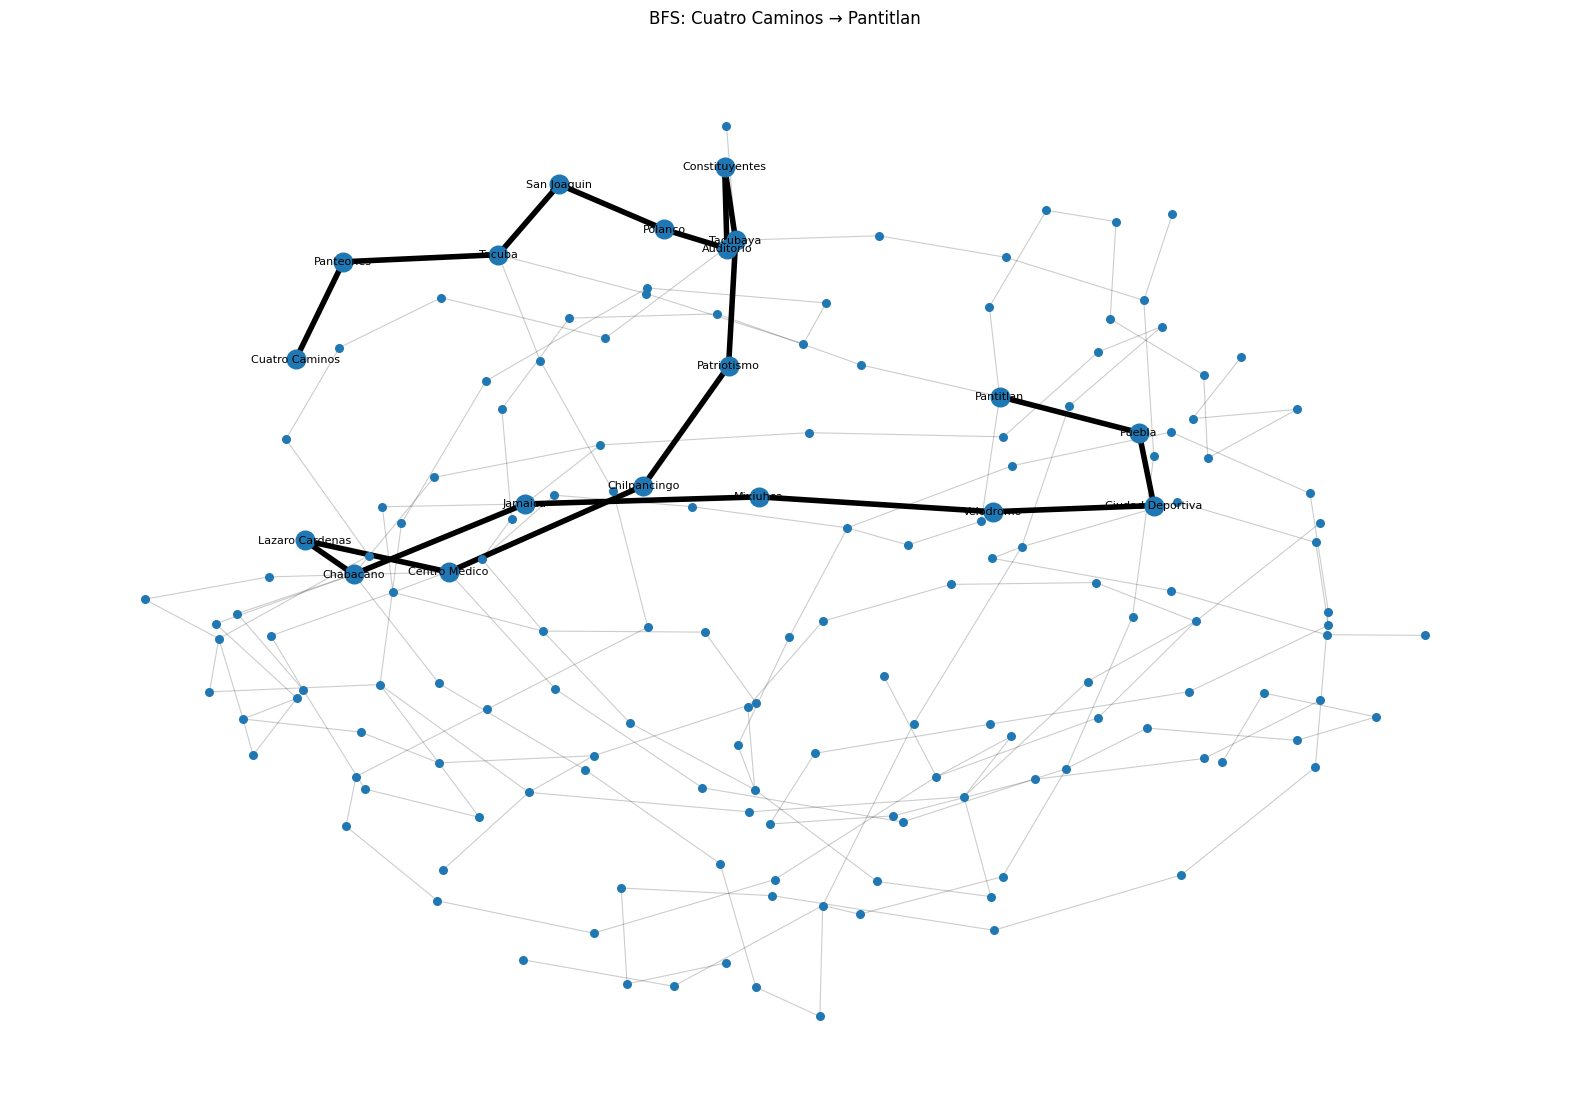

In [40]:
visualizar_ruta(
    G,
    bfs_1,
    "BFS: Cuatro Caminos → Pantitlan"
)

## **GRAFO BFS  Politecnico → Tasqueña**
## **GRAFO BFS Zapata → Oceania**

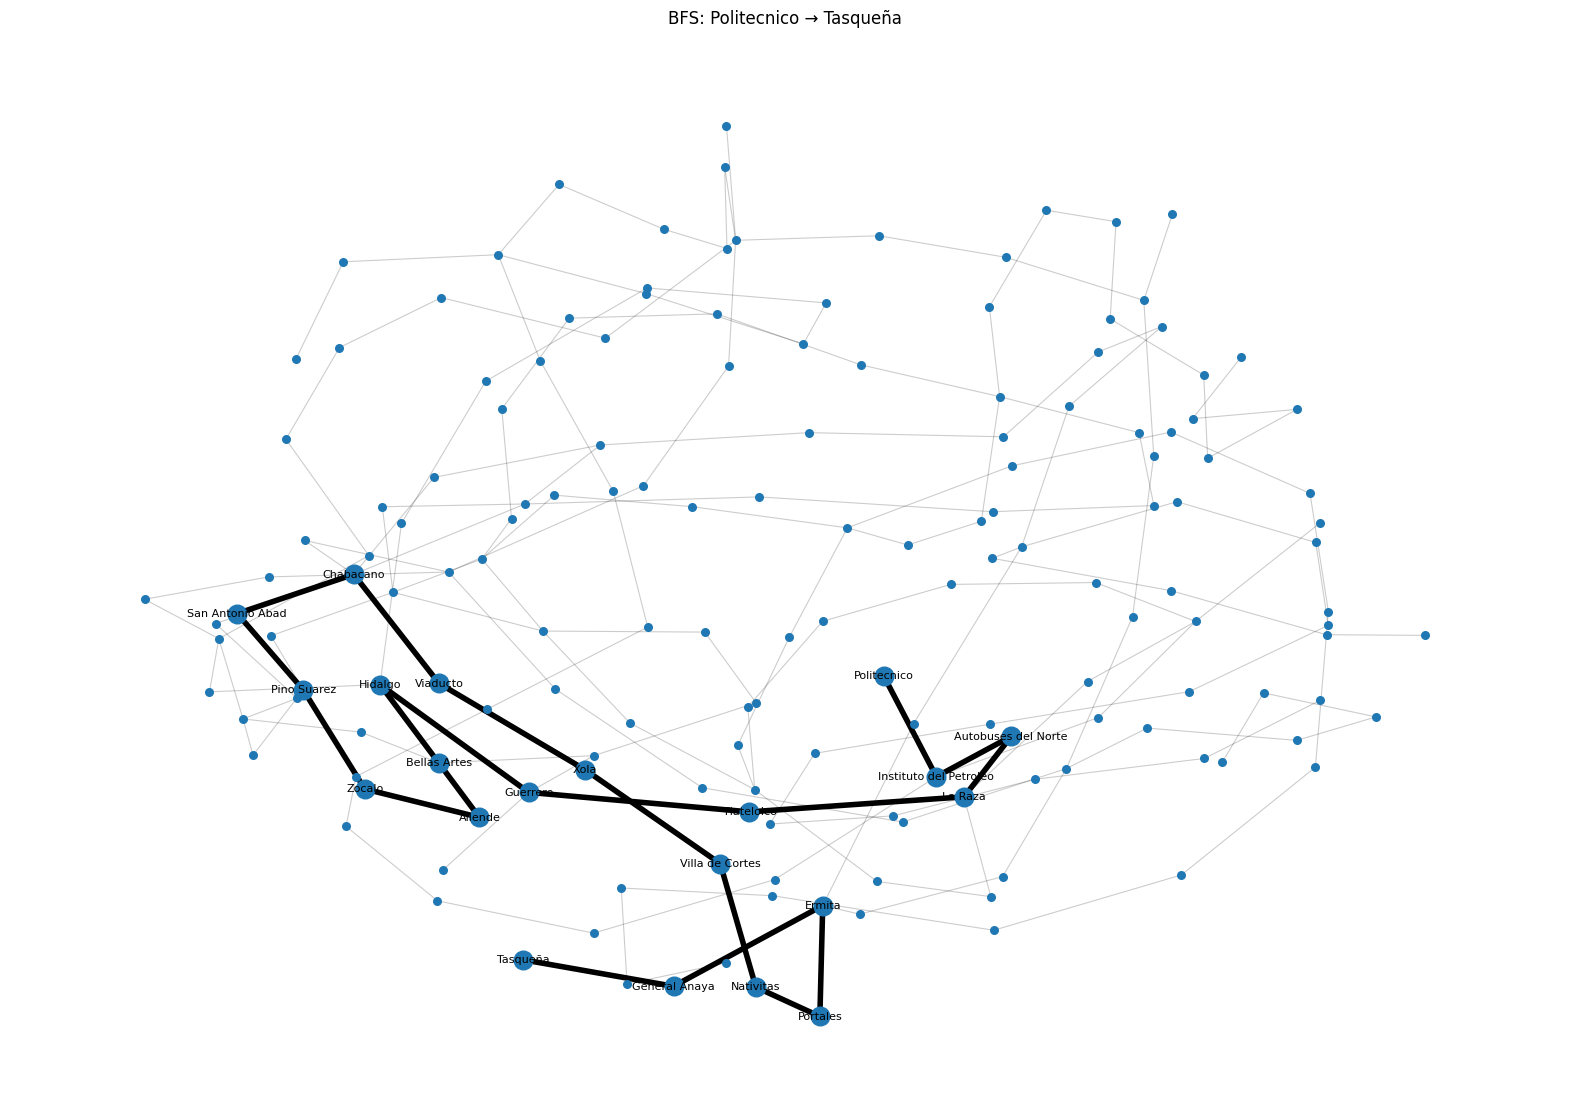

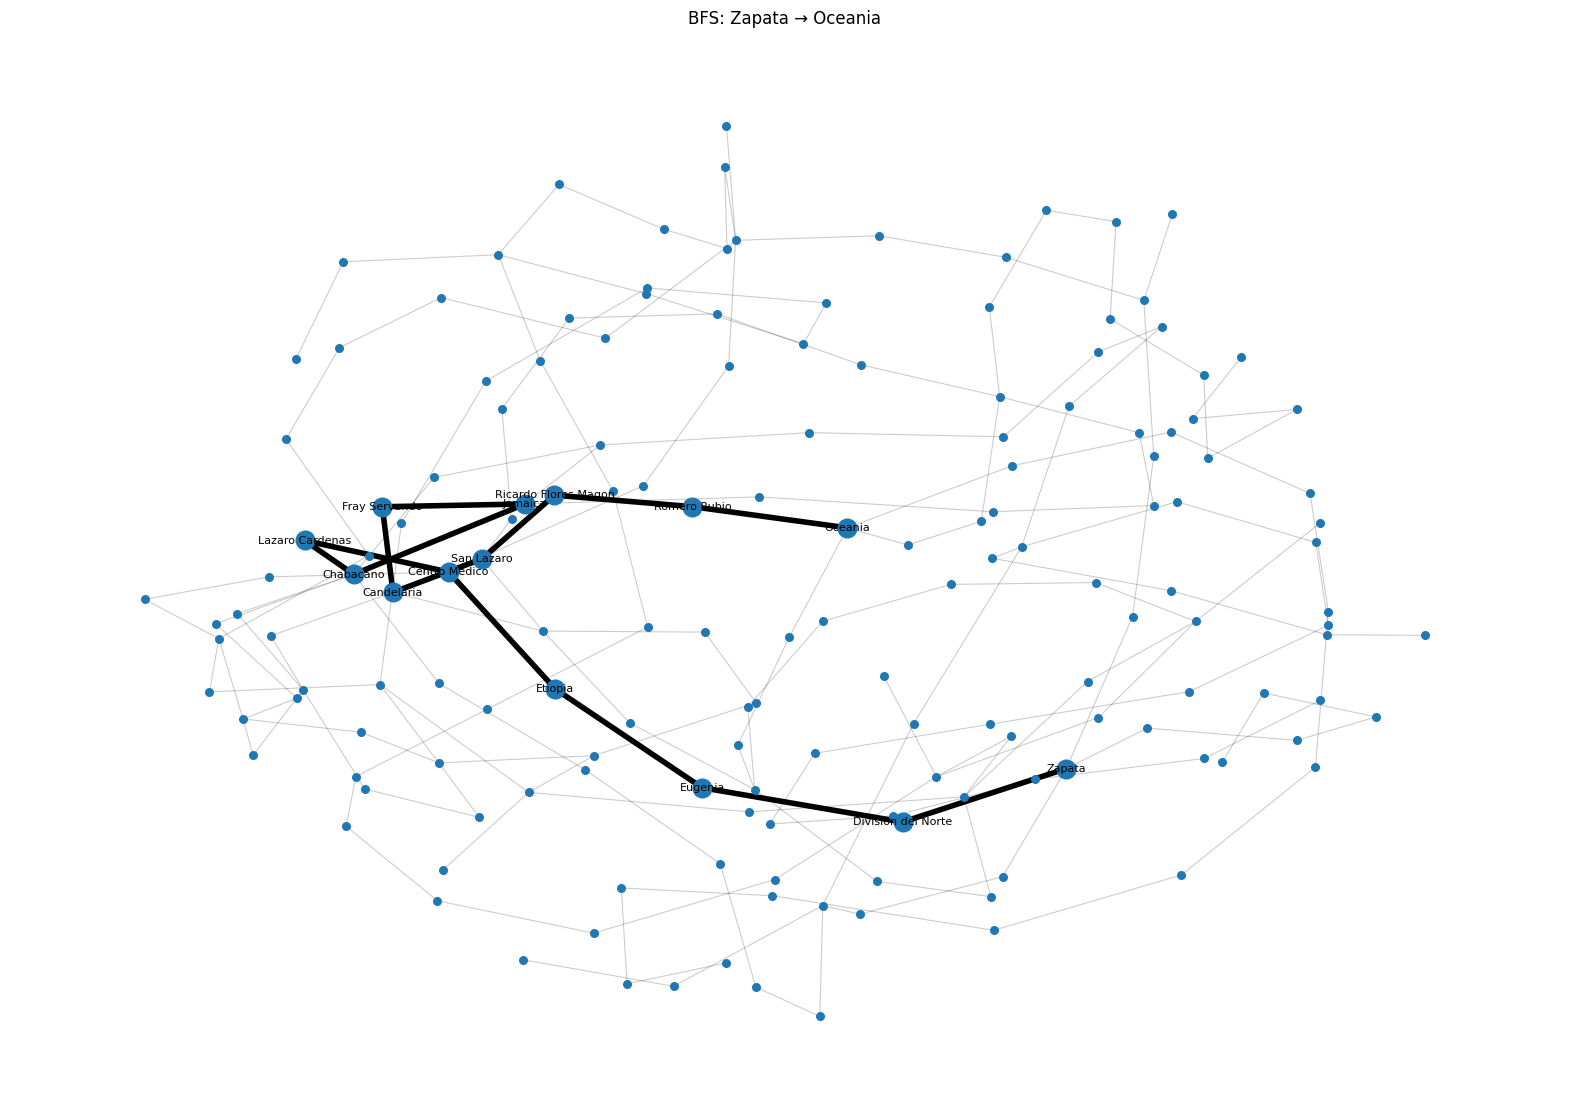

In [41]:
visualizar_ruta(
    G,
    bfs_2,
    "BFS: Politecnico → Tasqueña"
)

visualizar_ruta(
    G,
    bfs_3,
    "BFS: Zapata → Oceania"
)